### Explore the 7 waves of timeseries data 
- total number of participating countries
- #samples distribution of each country (COUNTRY_ALPHA: country abbreviation)
- #samples distribution of each wave (S002VS: wave)

### Select items from wave-7 data for next step analysis 
- COUNTRY_ALPHA
- 'survself', 'tradrat5', 'TradAgg', 'SurvSAgg'
- demographic groups
    - 'X001':'sex'
    - 'X003':'age'
    - 'X007':'marital status'
    - 'X025A_01':'highest educational level attained'
    - 'X028':'employment status'
    - 'X045':'social class'
    - 'X051':'ethnic group'
- Items with > 50% response rate


In [3]:
import pickle
import pandas as pd
import numpy as np
from collections import Counter
from scipy.stats import pearsonr

import seaborn as sns
import matplotlib.pyplot as plt

### Explore the 7 waves of timeseries data

In [ ]:
# takes 2 mins to load
df_data = pd.read_csv('./data/WVS_Time_Series_1981-2022_csv_v5_0.csv')

df_data.shape

(443488, 1046)

In [6]:
# save all columns (survey questions + meta data: details in the last section)
all_cols = list(df_data.columns)
len(all_cols)

1046

In [7]:
"A029" in all_cols

True

In [8]:
# 108 countries in total
counts = df_data['COUNTRY_ALPHA'].value_counts().sort_values(ascending=False)
counts

COUNTRY_ALPHA
ZAF    16786
IND    14313
COL    12082
MEX    11714
TUR    11704
       ...  
FRA     1001
PSE     1000
YEM     1000
NIR      447
DOM      417
Name: count, Length: 108, dtype: int64

Text(0, 0.5, '#samples')

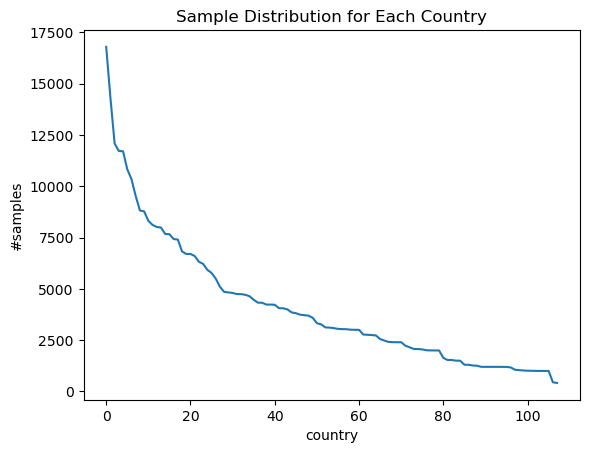

In [6]:
plt.plot(counts.values)
plt.title("Sample Distribution for Each Country")
plt.xlabel('country')
plt.ylabel('#samples')

In [7]:
# sample distribution of each wave
df_data['S002VS'].value_counts()

S002VS
7    97220
6    89565
5    83975
3    77818
4    60045
2    24558
1    10307
Name: count, dtype: int64

Text(0, 0.5, '#samples')

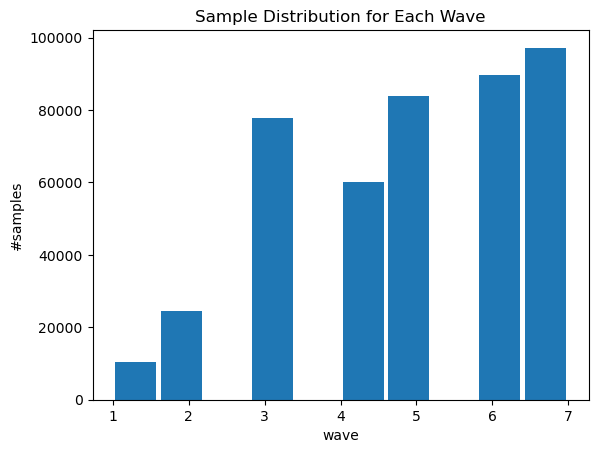

In [8]:
plt.hist(df_data['S002VS'], rwidth=0.9);
plt.title("Sample Distribution for Each Wave")
plt.xlabel('wave')
plt.ylabel('#samples')

In [6]:
df_data.head()[['COUNTRY_ALPHA','S002VS']]

,COUNTRY_ALPHA,S002VS
0,ALB,3
1,ALB,3
2,ALB,3
3,ALB,3
4,ALB,3


### Select items from wave-7 data for next step analysis 
- COUNTRY_ALPHA
- 'survself', 'tradrat5', 'TradAgg', 'SurvSAgg'
- demographic groups
    - 'X001':'sex' 
    - 'X003':'age' 
    - 'X007':'marital status'
    - 'X025A_01':'highest educational level attained' 
    - 'X028':'employment status' 
    - 'X045':'social class' 
    - 'X051':'ethnic group'
- Items with > 50% response rate
    - questions start from A, B, C, D, E, F, G, H, I, V, W, X, Y
    - A001 is df_wv7.columns[29]
    - the last 4 columns are: 'survself', 'tradrat5', 'TradAgg', 'SurvSAgg'


In [9]:
df_wv7 = df_data[df_data['S002VS'] == 7]
df_wv7.shape

(97220, 1046)

In [151]:
df_wv7.COUNTRY_ALPHA.value_counts().index

Index(['CAN', 'IDN', 'CHN', 'GBR', 'USA', 'TUR', 'NLD', 'HKG', 'BOL', 'SGP',
       'PAK', 'AUS', 'RUS', 'BRA', 'MEX', 'IND', 'MNG', 'DEU', 'COL', 'THA',
       'IRN', 'PER', 'JPN', 'MYS', 'UKR', 'KAZ', 'KEN', 'ROU', 'UZB', 'KOR',
       'NGA', 'ETH', 'GTM', 'ARM', 'TWN', 'ZWE', 'TUN', 'JOR', 'PHL', 'MMR',
       'BGD', 'TJK', 'VNM', 'SVK', 'CZE', 'ECU', 'KGZ', 'EGY', 'GRC', 'IRQ',
       'NIC', 'LBN', 'MAR', 'LBY', 'VEN', 'PRI', 'NZL', 'SRB', 'MDV', 'MAC',
       'AND', 'ARG', 'URY', 'CYP', 'CHL', 'NIR'],
      dtype='object', name='COUNTRY_ALPHA')

In [163]:
# identify columns with more than 50% response rate

import numbers

df_ctry_positive_rate = pd.DataFrame(index=list(df_wv7.COUNTRY_ALPHA.value_counts().index), 
                                     columns=df_wv7.columns[29:-4], dtype=float)

for ctry in df_ctry_positive_rate.index:
    df_ctry = df_wv7[df_wv7['COUNTRY_ALPHA'] == ctry]
    for col in df_ctry_positive_rate.columns:
        non_missing = df_ctry[col].dropna()
        # confirm that the responses are numerical values, not strings
        all_numeric = non_missing.map(lambda x: isinstance(x, numbers.Number)).all()
        
        if all_numeric:
            df_ctry_positive_rate.loc[ctry, col] = (non_missing > 0).sum() / df_ctry.shape[0]

In [ ]:
# only keep items if its response rate for **all** countries are greater than 0.5
# these items contain all the 124 items identified by Yilin
keep_items = []
for col in df_ctry_positive_rate.columns:
    if (df_ctry_positive_rate[col] >= 0.5).all():
        keep_items.append(col)
print(len(keep_items))


148


In [187]:
print(keep_items)

['A001', 'A002', 'A003', 'A004', 'A005', 'A006', 'A008', 'A009', 'A062', 'A165', 'A170', 'A173', 'B008', 'C001', 'C001_01', 'C002', 'C002_01', 'C006', 'C038', 'C039', 'C041', 'D001_B', 'D026_03', 'D026_05', 'D054', 'D057', 'D059', 'D060', 'D061', 'D066_B', 'D066_01', 'D078', 'E001', 'E003', 'E004', 'E005', 'E006', 'E015', 'E016', 'E018', 'E023', 'E025', 'E026', 'E027', 'E028', 'E034', 'E035', 'E036', 'E037', 'E039', 'E040', 'E069_01', 'E069_04', 'E069_05', 'E069_07', 'E069_08', 'E069_10', 'E069_12', 'E069_13', 'E069_14', 'E069_15', 'E069_40', 'E069_41', 'E069_54', 'E114', 'E115', 'E117', 'E117B', 'E124', 'E224', 'E225', 'E226', 'E227', 'E229', 'E233', 'E233A', 'E233B', 'E235', 'E236', 'E248B', 'E254B', 'E258B', 'E259B', 'E260B', 'E261B', 'E262B', 'E268', 'E277', 'E289', 'E286', 'E287', 'F025_WVS', 'F028', 'F028B', 'F034', 'F114A', 'F114B', 'F114C', 'F114D', 'F116', 'F117', 'F120', 'F121', 'F122', 'F123', 'F144_02', 'F202', 'F206', 'G007_18_B', 'G007_33_B', 'G007_34_B', 'G007_35_B', 'G0